# Input grids

**What this shows:** the ways to bring bathymetry, wind, currents, water levels and
other fields into SWAN: data sources, the fields `SwanDataGrid` can write, the
options that select the data, and hand-written input grids.

**Prerequisites:** [Tutorial 3: Input grids](../tutorial/03_input_grids.ipynb).

**You will learn:**

- how to read data from files, intake catalogues and in-memory datasets
- how to write vector fields such as currents, and scalar fields such as water level
- how the crop, buffer and time options select the data
- how to write `INPGRID` commands for files you prepare yourself, and constant winds

**Data used:** `etopo15s_perth.nc`, `era5-20230101.nc` and `catalog.yaml` in the
[`data/`](../data) folder, and small datasets created in the notebook.

## Setup

In [1]:
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from rompy.core.filters import Filter
from rompy.core.source import SourceFile, SourceIntake
from rompy.core.time import TimeRange
from rompy.logging import config as logging_config

from rompy_swan.data import SwanDataGrid
from rompy_swan.grid import SwanGrid

logging_config.update(level="WARNING")

DATA_DIR = Path("../data")
OUT_DIR = Path("_output") / "input_grids"
shutil.rmtree(OUT_DIR, ignore_errors=True)
OUT_DIR.mkdir(parents=True)

grid = SwanGrid(x0=114.5, y0=-32.8, dx=0.02, dy=0.02, nx=71, ny=66)
period = TimeRange(start="2023-01-01T00:00", end="2023-01-01T06:00", interval="1h")

## 1. Data sources

The `source` of a `SwanDataGrid` says where the data comes from. The sources come from
rompy, so they work the same for every model:

| Source | Reads |
|---|---|
| `SourceFile` | any file xarray opens (NetCDF, Zarr, GRIB, ...) |
| `SourceIntake` | a dataset from an [intake](https://intake.readthedocs.io) catalogue |
| `SourceDataset` | an xarray dataset already in memory |
| `SourceDatamesh` | a dataset from Oceanum's Datamesh |

An intake catalogue gives datasets names, so configurations do not depend on where
the files are:

In [2]:
wind = SwanDataGrid(
    var="wind",
    source=SourceIntake(dataset_id="era5", catalog_uri=DATA_DIR / "catalog.yaml"),
    z1="u10",
    z2="v10",
    coords={"x": "longitude", "y": "latitude"},
    filter=Filter(sort={"coords": ["latitude"]}),
    buffer=0.25,
)
print(wind.get(OUT_DIR, grid=grid, time=period))

INPGRID WIND REG 114.25 -33.0 0.0 7 7 0.25 0.25 EXC -99.0 NONSTATION 20230101.000000 1.00 HR
READINP WIND 1.0 'wind.grd' 3 0 1 0 FREE



## 2. Vector fields: currents

Currents, like wind, have two components: `z1` is eastward and `z2` northward. This
example builds an idealised southward current along the shelf break (like the
Leeuwin Current) as an in-memory dataset, with `SourceDataset`.

In [3]:
from rompy_binary_datasources.source import SourceDataset

lon = np.arange(114.3, 116.05, 0.05)
lat = np.arange(-33.0, -31.3, 0.05)
times = pd.date_range("2023-01-01", periods=7, freq="1h")
speed = -0.5 * np.exp(-(((lon - 114.9) / 0.15) ** 2))  # strongest at 114.9°E
vo = np.broadcast_to(speed, (len(times), len(lat), len(lon)))
currents = xr.Dataset(
    {"uo": (("time", "lat", "lon"), np.zeros_like(vo)), "vo": (("time", "lat", "lon"), vo)},
    coords={"time": times, "lat": lat, "lon": lon},
)

current = SwanDataGrid(
    var="current",
    source=SourceDataset(obj=currents),
    z1="uo",
    z2="vo",
    coords={"x": "lon", "y": "lat"},
)
print(current.get(OUT_DIR, grid=grid, time=period))

INPGRID CURRENT REG 114.55 -32.75 0.0 27 25 0.05 0.05 EXC -99.0 NONSTATION 20230101.000000 1.00 HR
READINP CURRENT 1.0 'current.grd' 3 0 1 0 FREE



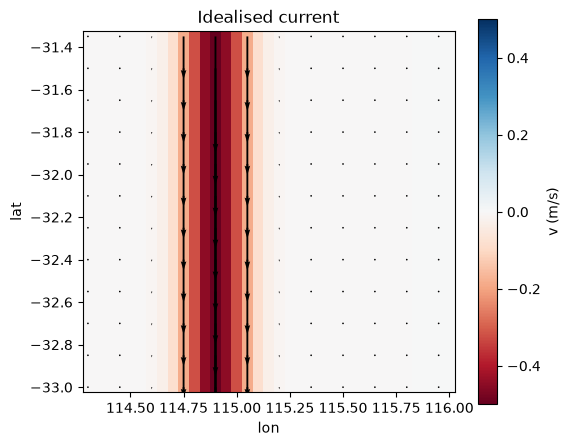

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
first = currents.isel(time=0)
first.vo.plot(ax=ax, cmap="RdBu", vmin=-0.5, vmax=0.5, cbar_kwargs={"label": "v (m/s)"})
ax.quiver(first.lon[::3], first.lat[::3], first.uo[::3, ::3], first.vo[::3, ::3])
ax.set_aspect("equal")
ax.set_title("Idealised current");

## 3. Scalar fields: water level and others

Scalar fields need only `z1`. A water level adds to the depths, here a 30 cm rise
over six hours:

In [5]:
wlevel_data = xr.Dataset(
    {"zos": (("time", "lat", "lon"), np.zeros((len(times), len(lat), len(lon))))},
    coords={"time": times, "lat": lat, "lon": lon},
)
wlevel_data["zos"] += xr.DataArray(np.linspace(0, 0.3, len(times)), dims="time")

wlevel = SwanDataGrid(
    var="wlevel", source=SourceDataset(obj=wlevel_data), z1="zos", coords={"x": "lon", "y": "lat"}
)
print(wlevel.get(OUT_DIR, grid=grid, time=period))

INPGRID WLEVEL REG 114.55 -32.75 0.0 27 25 0.05 0.05 EXC -99.0 NONSTATION 20230101.000000 1.00 HR
READINP WLEVEL 1.0 'wlevel.grd' 3 0 1 0 FREE



The other fields SWAN reads work the same way. The `var` values are:

In [6]:
from rompy_swan.types import GridOptions

print([option.value for option in GridOptions])

['bottom', 'wlevel', 'current', 'vx', 'vy', 'wind', 'wx', 'wy', 'friction', 'nplants', 'turbvisc', 'mudlayer', 'aice', 'hice', 'hss', 'tss']


`wx`/`wy` and `vx`/`vy` are single components of wind and current; `friction`,
`nplants`, `turbvisc`, `mudlayer`, `aice`, `hice`, `hss` and `tss` are the inputs of
the matching physics options.

rompy-swan writes every field except the bottom as a time series, which needs at
least two times. For a field that does not change, such as a friction map, give the
dataset two identical times or write the input grid by hand (section 6).

## 4. Selecting the data

These options come from rompy's data classes:

| Option | Effect |
|---|---|
| `crop_data` | crop to the grid and period (default `True`) |
| `buffer` | extra distance around the grid, in the grid's units |
| `time_buffer` | extra times before and after the period, e.g. `[1, 1]` |
| `filter` | sort, subset, crop or rename the data when it is opened |
| `variables` | variables to read (by default `z1` and `z2`) |
| `coords` | names of the x, y and time coordinates in the dataset |

The buffer matters for coarse data. Here are the wind points kept with two buffers:

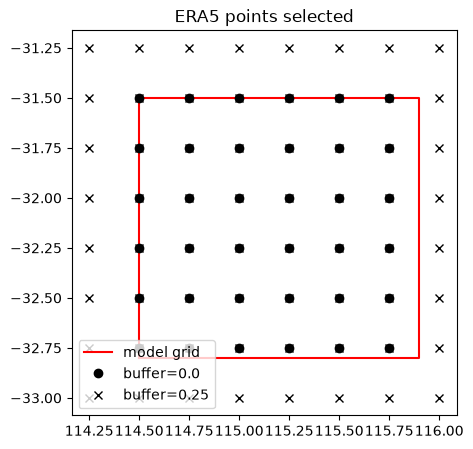

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
x0, y0, x1, y1 = grid.bbox()
ax.plot([x0, x1, x1, x0, x0], [y0, y0, y1, y1, y0], "r", label="model grid")
for buffer, marker in [(0.0, "o"), (0.25, "x")]:
    data = wind.model_copy(update={"buffer": buffer, "filter": Filter(sort={"coords": ["latitude"]})})
    data.get(OUT_DIR, grid=grid, time=period)
    lons, lats = np.meshgrid(data.ds.longitude, data.ds.latitude)
    ax.plot(lons, lats, marker, color="k", label=f"buffer={buffer}")
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), loc="lower left")
ax.set_aspect("equal")
ax.set_title("ERA5 points selected");

Without a buffer, the 0.25° wind points do not reach the edges of the model grid, and
SWAN would set the wind to zero there.

## 5. Using the input grids in a model

`DataInterface` collects them: the `bottom` and a list of other `input` grids, each
with a different `var`.

In [8]:
from rompy_swan.interface import DataInterface

bottom = SwanDataGrid(
    var="bottom",
    source=SourceFile(uri=DATA_DIR / "etopo15s_perth.nc"),
    z1="z",
    fac=-1.0,
    coords={"x": "longitude", "y": "latitude"},
    buffer=0.1,
)
inpgrid = DataInterface(bottom=bottom, input=[wind, current, wlevel])
print(inpgrid.render(OUT_DIR, grid, period))

INPGRID BOTTOM REG 114.402083333 -32.8979166667 0.0 383 359 0.00416666666667 0.00416666666667 EXC 99.0
READINP BOTTOM -1.0 'bottom.grd' 3 FREE

INPGRID WIND REG 114.25 -33.0 0.0 7 7 0.25 0.25 EXC -99.0 NONSTATION 20230101.000000 1.00 HR
READINP WIND 1.0 'wind.grd' 3 0 1 0 FREE

INPGRID CURRENT REG 114.55 -32.75 0.0 27 25 0.05 0.05 EXC -99.0 NONSTATION 20230101.000000 1.00 HR
READINP CURRENT 1.0 'current.grd' 3 0 1 0 FREE

INPGRID WLEVEL REG 114.55 -32.75 0.0 27 25 0.05 0.05 EXC -99.0 NONSTATION 20230101.000000 1.00 HR
READINP WLEVEL 1.0 'wlevel.grd' 3 0 1 0 FREE



## 6. Hand-written input grids

If you prepare the input files yourself, or use a curvilinear or unstructured grid,
describe them with the `inpgrid` components and `INPGRIDS`. rompy-swan then writes
the commands but does not create or check the files. A constant wind is also written
this way.

In [9]:
from rompy_swan.components.group import INPGRIDS
from rompy_swan.components.inpgrid import REGULAR, WIND
from rompy_swan.subcomponents.readgrid import READINP

inpgrids = INPGRIDS(
    inpgrids=[
        REGULAR(
            grid_type="bottom",
            xpinp=114.4,
            ypinp=-32.9,
            alpinp=0.0,
            mxinp=383,
            myinp=359,
            dxinp=0.0041667,
            dyinp=0.0041667,
            excval=-99.0,
            readinp=READINP(fname1="my_bathymetry.bot", fac=-1.0),
        ),
        WIND(vel=10.0, dir=225.0),
    ]
)
print(inpgrids.render())

INPGRID BOTTOM REGULAR xpinp=114.4 ypinp=-32.9 alpinp=0.0 mxinp=383 myinp=359 dxinp=0.0041667 dyinp=0.0041667 EXCEPTION excval=-99.0
READINP BOTTOM fac=-1.0 fname1='my_bathymetry.bot' idla=1 nhedf=0 nhedt=0 nhedvec=0 FREE

WIND vel=10.0 dir=225.0


A `SwanConfig` takes either a `DataInterface` or `INPGRIDS`, not both.

## Summary

- Sources read files, catalogues and in-memory datasets; they come from rompy.
- `var`, `z1`/`z2` and `fac` say which SWAN field to write and from which variables.
- `buffer`, `time_buffer`, `filter` and `crop_data` select the data; check coarse
  data covers the grid.
- `INPGRIDS` writes commands for files you prepare yourself and for constant winds.